In [44]:
# Standard data manipulation and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Everything we need from sklearn for building and evaluating the logistic regression model
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay
)
from sklearn.pipeline import Pipeline

# Suppress warnings so the output stays clean and readable
import warnings
warnings.filterwarnings('ignore')

# SMOTE helps us deal with class imbalance by synthetically generating minority class samples.
# If it's not installed we'll just fall back to class_weight='balanced' inside the model itself.
try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
except ImportError:
    SMOTE_AVAILABLE = False
    print("imbalanced-learn not installed — will use class_weight='balanced' instead.")
    print("Install with: pip install imbalanced-learn")

print('All imports successful.')

imbalanced-learn not installed — will use class_weight='balanced' instead.
Install with: pip install imbalanced-learn
All imports successful.


In [45]:
from pathlib import Path
import os

# Robustly find the project root whether Jupyter is launched from the
# project root or from inside the notebooks/ folder.
_cwd = Path(os.getcwd())
_data_folder = 'diabetes+130-us+hospitals+for+years+1999-2008'

if (_cwd / _data_folder).exists():
    ROOT = _cwd                  # launched from project root
elif (_cwd.parent / _data_folder).exists():
    ROOT = _cwd.parent           # launched from notebooks/
else:
    raise FileNotFoundError(
        f"Cannot find '{_data_folder}'. "
        "Run Jupyter from the project root or from the notebooks/ folder."
    )

DATA_PATH     = ROOT / _data_folder / 'diabetic_data.csv'
RESULTS_DIR   = ROOT / 'results'
PROCESSED_DIR = ROOT / 'data' / 'processed'

# Make sure output directories exist before any plt.savefig() calls
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)
print(f'Project root : {ROOT}')
print(f'Data path    : {DATA_PATH}')
print(f'Shape        : {df.shape}')
df.head(3)










# Quick look at column types and null counts — useful before any cleaning
df.info()

Project root : /Users/nafisat/Desktop/DS4400FinalProject
Data path    : /Users/nafisat/Desktop/DS4400FinalProject/diabetes+130-us+hospitals+for+years+1999-2008/diabetic_data.csv
Shape        : (101766, 50)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code        

Target value counts:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


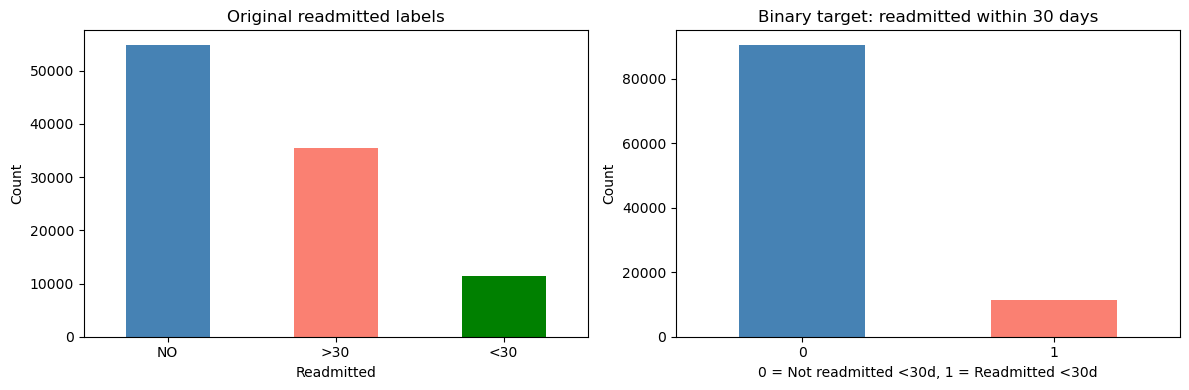


Class balance: 11357/101766 = 11.2% positive (readmitted <30d)


In [46]:
# The original target column has three values: 'NO', '>30', and '<30'.
# Since we only care about readmissions within 30 days, we'll convert this
# into a binary label: 1 if readmitted <30 days, 0 for everything else.
print('Target value counts:')
print(df['readmitted'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left plot: original 3-class distribution so we can see what we're starting with
df['readmitted'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon', 'green'])
axes[0].set_title('Original readmitted labels')
axes[0].set_xlabel('Readmitted')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Right plot: our binarized version — this is the actual prediction target
df['readmitted_30'] = (df['readmitted'] == '<30').astype(int)
df['readmitted_30'].value_counts().plot(kind='bar', ax=axes[1], color=['steelblue', 'salmon'])
axes[1].set_title('Binary target: readmitted within 30 days')
axes[1].set_xlabel('0 = Not readmitted <30d, 1 = Readmitted <30d')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

pos = df['readmitted_30'].sum()
total = len(df)
print(f'\nClass balance: {pos}/{total} = {pos/total*100:.1f}% positive (readmitted <30d)')

In [47]:
# This dataset uses '?' as a placeholder for missing values instead of NaN,
# so we need to manually count those before deciding how to handle each column.
missing_counts = (df == '?').sum()
missing_pct = (missing_counts / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing_counts, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)
print('Columns with ? missing values:')
print(missing_df)
# weight is nearly 97% missing — not worth keeping
# payer_code and medical_specialty are ~40-50% missing — also dropping those

Columns with ? missing values:
                   missing_count  missing_pct
weight                     98569        96.86
medical_specialty          49949        49.08
payer_code                 40256        39.56
race                        2273         2.23
diag_3                      1423         1.40
diag_2                       358         0.35
diag_1                        21         0.02


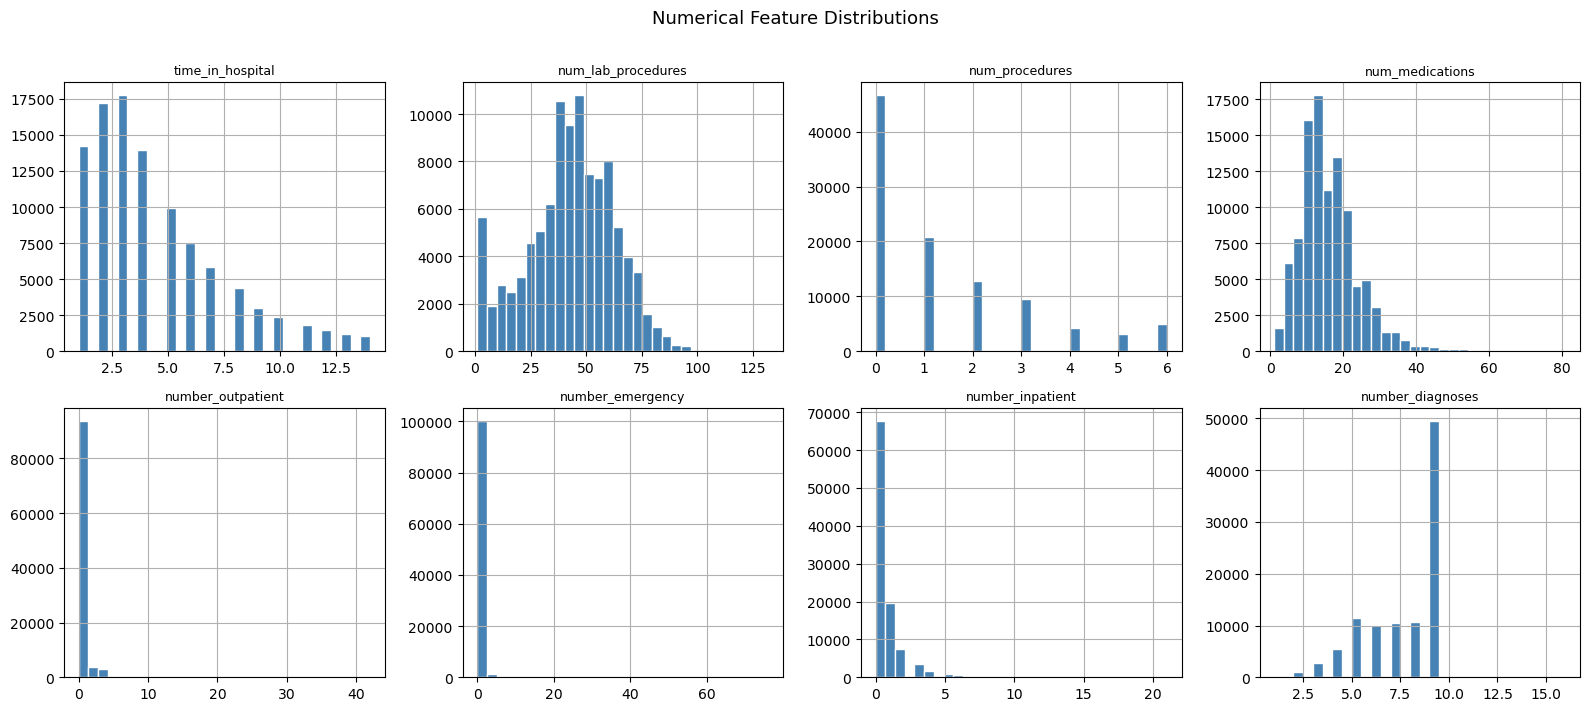

In [48]:
# shows how the features are distrbuted 
num_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
            'num_medications', 'number_outpatient', 'number_emergency',
            'number_inpatient', 'number_diagnoses']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, num_cols):
    df[col].hist(bins=30, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
plt.suptitle('Numerical Feature Distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Data Preprocessing

In [49]:
# 4.1  Drop columns we can't use

# weight: 97% missing, not recoverable — drop it
# payer_code: ~40% missing and insurance type isn't a clinical predictor we want to rely on
# medical_specialty: ~49% missing and would add noise more than signal at this level
# encounter_id / patient_nbr: just identifier columns, no predictive value
DROP_COLS = ['encounter_id', 'patient_nbr', 'weight', 'payer_code', 'medical_specialty']
df.drop(columns=DROP_COLS, inplace=True)

# We already created readmitted_30, so the original text column can go
df.drop(columns=['readmitted'], inplace=True)

print(f'Shape after dropping columns: {df.shape}')

Shape after dropping columns: (101766, 45)


In [50]:
# 4.2  Handle missing values

# Convert '?' to proper NaN so pandas knows they're missing
df.replace('?', np.nan, inplace=True)

# Race and the three diagnosis columns have a small fraction of missing rows.
# Since they represent <3% of the data, we drop those rows rather than imputing,
# which keeps the dataset clean without meaningful data loss.
before = len(df)
df.dropna(subset=['race', 'diag_1', 'diag_2', 'diag_3'], inplace=True)
after = len(df)
print(f'Rows dropped for missing race/diag: {before - after} ({(before - after)/before*100:.2f}%)')
print(f'Shape after row removal: {df.shape}')
print('Remaining nulls:', df.isnull().sum().sum())
# Note: A1Cresult and max_glu_serum still have many nulls — handled below
# with ordinal encoding (treating missing as 'not tested')

Rows dropped for missing race/diag: 3713 (3.65%)
Shape after row removal: (98053, 45)
Remaining nulls: 174705


In [51]:
# 4.3  Remove patients who died or went to hospice

# These patients literally cannot be readmitted, so including them
# would artificially inflate our '0' class and mislead the model.
# discharge_disposition_id codes: 11=Expired, 13=Hospice/home, 14=Hospice/facility,
# 19-21=Expired variants (Medicaid only)
exclude_discharge = [11, 13, 14, 19, 20, 21]
df = df[~df['discharge_disposition_id'].isin(exclude_discharge)].copy()
print(f'Shape after removing expired/hospice: {df.shape}')

Shape after removing expired/hospice: (95673, 45)


In [52]:
# 4.4  Map ICD-9 diagnosis codes to broad disease categories

# The raw ICD-9 codes are too granular — there are thousands of unique values
# and most appear rarely. Grouping them into 9 clinical categories gives the
# model something meaningful to work with.
def map_icd9(code):
    """Map an ICD-9 code string to one of 9 broad disease categories."""
    if pd.isna(code):
        return 'Other'
    code_str = str(code).upper()
    # E and V codes (external causes, supplemental) → Other
    if code_str.startswith('E') or code_str.startswith('V'):
        return 'Other'
    try:
        c = float(code_str)
    except ValueError:
        return 'Other'
    if 390 <= c <= 459 or c == 785:
        return 'Circulatory'
    elif 460 <= c <= 519 or c == 786:
        return 'Respiratory'
    elif 520 <= c <= 579 or c == 787:
        return 'Digestive'
    elif 250 <= c < 251:
        return 'Diabetes'
    elif 800 <= c <= 999:
        return 'Injury'
    elif 710 <= c <= 739:
        return 'Musculoskeletal'
    elif 580 <= c <= 629 or c == 788:
        return 'Genitourinary'
    elif 140 <= c <= 239:
        return 'Neoplasms'
    else:
        return 'Other'

for col in ['diag_1', 'diag_2', 'diag_3']:
    df[col] = df[col].apply(map_icd9)

print('Diagnosis category counts (diag_1):')
print(df['diag_1'].value_counts())
print(f'\nUnique categories: {sorted(df["diag_1"].unique())}')

Diagnosis category counts (diag_1):
diag_1
Circulatory        28888
Other              17169
Respiratory        13511
Digestive           9045
Diabetes            7870
Injury              6590
Genitourinary       4870
Musculoskeletal     4717
Neoplasms           3013
Name: count, dtype: int64

Unique categories: ['Circulatory', 'Diabetes', 'Digestive', 'Genitourinary', 'Injury', 'Musculoskeletal', 'Neoplasms', 'Other', 'Respiratory']


In [53]:
# 4.5  Encode medication columns

# Each of the 23 medication columns records whether the drug dosage was:
# No (not prescribed), Steady (unchanged), Up (increased), or Down (decreased).
# We encode these as 0/1/2/3 — preserving the ordinal direction of change.
MED_COLS = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
    'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
    'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
    'examide', 'citoglipton', 'insulin', 'glyburide-metformin',
    'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone'
]

med_map = {'No': 0, 'Steady': 1, 'Up': 2, 'Down': 3}
for col in MED_COLS:
    df[col] = df[col].map(med_map).fillna(0).astype(int)

print('Medication columns encoded.')

Medication columns encoded.


In [54]:
# 4.6  Encode the remaining categorical columns

# Simple binary flags
df['change'] = (df['change'] == 'Ch').astype(int)
df['diabetesMed'] = (df['diabetesMed'] == 'Yes').astype(int)
df['gender'] = (df['gender'] == 'Female').astype(int)

# A1C and glucose levels are ordinal — higher values = worse glycemic control.
# Missing (None) most likely means the test wasn't done, so we encode it as 0.
a1c_map = {'None': 0, 'Norm': 1, '>7': 2, '>8': 3}
glu_map = {'None': 0, 'Norm': 1, '>200': 2, '>300': 3}
df['A1Cresult'] = df['A1Cresult'].map(a1c_map).fillna(0).astype(int)
df['max_glu_serum'] = df['max_glu_serum'].map(glu_map).fillna(0).astype(int)

# Age is given as a bracket like '[50-60)' — convert to midpoint so the model
# can treat it as a continuous numeric variable.
age_map = {
    '[0-10)': 5, '[10-20)': 15, '[20-30)': 25, '[30-40)': 35,
    '[40-50)': 45, '[50-60)': 55, '[60-70)': 65, '[70-80)': 75,
    '[80-90)': 85, '[90-100)': 95
}
df['age'] = df['age'].map(age_map).fillna(df['age'].map(age_map).median())

# Race and the three diagnosis category columns are nominal — one-hot encode them.
# drop_first=True avoids the dummy variable trap.
CAT_OHE = ['race', 'diag_1', 'diag_2', 'diag_3']
df = pd.get_dummies(df, columns=CAT_OHE, drop_first=True)

print(f'Shape after encoding: {df.shape}')
df.head(2)

Shape after encoding: (95673, 69)


,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,...,diag_2_Other,diag_2_Respiratory,diag_3_Diabetes,diag_3_Digestive,diag_3_Genitourinary,diag_3_Injury,diag_3_Musculoskeletal,diag_3_Neoplasms,diag_3_Other,diag_3_Respiratory
1,1,15,1,1,7,3,59,0,18,0,...,False,False,False,False,False,False,False,False,True,False
2,1,25,1,1,7,2,11,5,13,2,...,False,False,False,False,False,False,False,False,True,False


## Feature Engineering

In [55]:
# Create new features from existing ones

# Patients with high prior utilization (many previous visits) are often sicker overall.
df['total_prior_visits'] = df['number_outpatient'] + df['number_emergency'] + df['number_inpatient']

# If many medications had their dosage changed, the patient's regimen may be unstable.
med_change_cols = [c for c in MED_COLS if c in df.columns]
df['n_meds_changed'] = df[med_change_cols].apply(lambda row: (row != 0).sum(), axis=1)

# Total number of medications actively being used (any dosage level > 0).
df['med_complexity'] = df[med_change_cols].apply(lambda row: (row > 0).sum(), axis=1)

# How many procedures happened per day — a rough proxy for care intensity.
df['procedures_per_day'] = df['num_procedures'] / df['time_in_hospital'].replace(0, 1)

print('New features created: total_prior_visits, n_meds_changed, med_complexity, procedures_per_day')

New features created: total_prior_visits, n_meds_changed, med_complexity, procedures_per_day


## Train / Test Split

In [56]:
TARGET = 'readmitted_30'
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Cast everything to numeric (bool columns from get_dummies may sneak through)
X = X.select_dtypes(include=[np.number])

# 80/20 split — stratify=y is important because our classes are imbalanced (~11% positive)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train positive rate: {y_train.mean():.3f}')
print(f'Test  positive rate: {y_test.mean():.3f}')

Train: (76538, 44), Test: (19135, 44)
Train positive rate: 0.115
Test  positive rate: 0.115


## Handle Class Imbalance

In [57]:
# Only 11% of patients were actually readmitted within 30 days.
# SMOTE creates synthetic minority-class examples so the model sees a balanced
# training set. IMPORTANT: only apply to training data — never the test set.
if SMOTE_AVAILABLE:
    sm = SMOTE(random_state=42)
    X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)
    print(f'After SMOTE — Train shape: {X_train_bal.shape}')
    print(f'Class balance: {pd.Series(y_train_bal).value_counts().to_dict()}')
else:
    # Fallback if imbalanced-learn is not installed
    X_train_bal, y_train_bal = X_train, y_train
    print('SMOTE not available — downstream models should use class_weight="balanced".')
    print('Install with: pip install imbalanced-learn')

SMOTE not available — downstream models should use class_weight="balanced".
Install with: pip install imbalanced-learn


## Feature Scaling

In [58]:
# Fit the scaler only on training data, then apply the same transformation to the test set.
# Fitting on the test set would leak information about the test distribution.
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_bal)
X_test_sc  = scaler.transform(X_test)
print('Scaling applied.')

Scaling applied.


## Save Processed Data

In [59]:
import joblib

# Save everything other notebooks need
joblib.dump(X_train_sc,   PROCESSED_DIR / 'X_train_sc.pkl')
joblib.dump(X_test_sc,    PROCESSED_DIR / 'X_test_sc.pkl')
joblib.dump(y_train_bal,  PROCESSED_DIR / 'y_train_bal.pkl')
joblib.dump(y_test,       PROCESSED_DIR / 'y_test.pkl')
joblib.dump(scaler,       PROCESSED_DIR / 'scaler.pkl')
joblib.dump(X.columns.tolist(), PROCESSED_DIR / 'feature_names.pkl')
joblib.dump(SMOTE_AVAILABLE,    PROCESSED_DIR / 'smote_available.pkl')

# Also save the fully processed DataFrame (useful for tree-based models that
# don't need scaling — they can re-split themselves if needed)
df.to_csv(PROCESSED_DIR / 'diabetic_processed.csv', index=False)

print('Saved to', PROCESSED_DIR)
print('  X_train_sc.pkl    — scaled training features')
print('  X_test_sc.pkl     — scaled test features')
print('  y_train_bal.pkl   — training labels (SMOTE-balanced)')
print('  y_test.pkl        — test labels (original distribution)')
print('  scaler.pkl        — fitted StandardScaler')
print('  feature_names.pkl — ordered list of feature column names')
print('  smote_available.pkl — bool: was SMOTE applied?')
print('  diabetic_processed.csv — full processed DataFrame')

Saved to /Users/nafisat/Desktop/DS4400FinalProject/data/processed
  X_train_sc.pkl    — scaled training features
  X_test_sc.pkl     — scaled test features
  y_train_bal.pkl   — training labels (SMOTE-balanced)
  y_test.pkl        — test labels (original distribution)
  scaler.pkl        — fitted StandardScaler
  feature_names.pkl — ordered list of feature column names
  smote_available.pkl — bool: was SMOTE applied?
  diabetic_processed.csv — full processed DataFrame
